# Exercise: Naive Bayes phân loại review Positive / Negative

Notebook này dùng **dataset thật trên Kaggle**: **IMDB Dataset of 50K Movie Reviews**.

Mục tiêu:

- Đọc dữ liệu review thật từ Kaggle
- Làm sạch text cơ bản
- Biến text thành vector số bằng `CountVectorizer` hoặc `TfidfVectorizer`
- Train model **Multinomial Naive Bayes**
- Đánh giá bằng Accuracy, Precision, Recall, F1-score, Confusion Matrix
- Dự đoán review mới là `positive` hay `negative`

Dataset có 2 cột chính:

| Column | Ý nghĩa |
|---|---|
| `review` | Nội dung review phim |
| `sentiment` | Nhãn cảm xúc: `positive` hoặc `negative` |

## 1. Cài đặt thư viện

Chạy cell dưới nếu máy chưa có thư viện cần thiết.

Lưu ý:

- Nếu chạy trên Kaggle Notebook thì thường đã có sẵn `pandas`, `sklearn`, `matplotlib`, `seaborn`.
- Nếu chạy local Jupyter thì nên cài thêm `kagglehub` để tải dataset từ Kaggle.

In [ ]:
# Nếu thiếu thư viện, mở comment dòng dưới rồi chạy:
# !pip install kagglehub pandas scikit-learn matplotlib seaborn joblib

## 2. Import thư viện

In [1]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

## 3. Tải dataset thật từ Kaggle

Ta dùng dataset:

```text
lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
```

Nếu bị lỗi quyền Kaggle, có 2 cách xử lý:

1. Đăng nhập Kaggle và cấu hình Kaggle API token.
2. Tải thủ công file `IMDB Dataset.csv` từ Kaggle, sau đó đặt cùng thư mục với notebook này.

In [2]:
# Cách 1: Tải trực tiếp bằng kagglehub
# Nếu bạn đã có file CSV local, có thể bỏ qua cell này và chạy cell fallback bên dưới.

try:
    import kagglehub
    dataset_path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
    print("Dataset downloaded to:", dataset_path)
    print("Files:", os.listdir(dataset_path))
except Exception as e:
    dataset_path = None
    print("Không tải được bằng kagglehub.")
    print("Lý do:", e)
    print("Bạn có thể tải thủ công file 'IMDB Dataset.csv' và đặt cùng thư mục notebook.")

100%|██████████| 25.7M/25.7M [00:02<00:00, 11.8MB/s]

Extracting files...


Dataset downloaded to: C:\Users\ASUS\.cache\kagglehub\datasets\lakshmi25npathi\imdb-dataset-of-50k-movie-reviews\versions\1
Files: ['IMDB Dataset.csv']


## 4. Đọc dữ liệu

Cell này sẽ tự tìm file CSV theo 2 hướng:

- Nếu tải bằng `kagglehub` thành công → đọc từ thư mục tải về
- Nếu không → đọc file local `IMDB Dataset.csv`

In [3]:
csv_path = None

if dataset_path is not None:
    for file in os.listdir(dataset_path):
        if file.endswith(".csv"):
            csv_path = os.path.join(dataset_path, file)
            break

if csv_path is None and os.path.exists("IMDB Dataset.csv"):
    csv_path = "IMDB Dataset.csv"

if csv_path is None:
    raise FileNotFoundError("Không tìm thấy file CSV. Hãy tải 'IMDB Dataset.csv' và đặt cùng thư mục notebook.")

print("CSV path:", csv_path)

df = pd.read_csv(csv_path)
df.head()

CSV path: C:\Users\ASUS\.cache\kagglehub\datasets\lakshmi25npathi\imdb-dataset-of-50k-movie-reviews\versions\1\IMDB Dataset.csv


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## 5. Kiểm tra dữ liệu ban đầu

Ta cần kiểm tra:

- Số dòng, số cột
- Tên cột
- Có missing value không
- Số lượng review positive / negative có cân bằng không

In [4]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nLabel distribution:")
print(df['sentiment'].value_counts())

Shape: (50000, 2)
Columns: ['review', 'sentiment']

Missing values:
review       0
sentiment    0
dtype: int64

Label distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


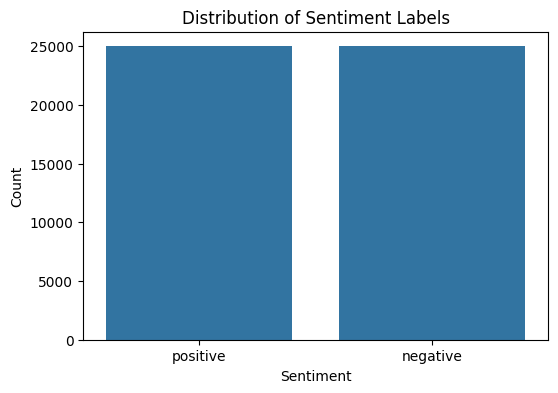

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sentiment')
plt.title("Distribution of Sentiment Labels")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

## 6. Xem thử một vài review

Review thật thường có:

- Chữ hoa / chữ thường lẫn lộn
- Dấu câu
- HTML tag như `<br />`
- Từ ngắn, từ dài, câu rất dài

Vì vậy ta cần text preprocessing.

In [6]:
for i in range(3):
    print("Review", i+1)
    print(df.loc[i, 'review'][:800])
    print("Sentiment:", df.loc[i, 'sentiment'])
    print("-"*100)

Review 1
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, 
Sentiment: positive
----------------------------------------------------------------------------------------------------
Review 2
A wonderful little production. <br /><br />The filming techn

## 7. Text preprocessing

Ta tạo hàm làm sạch text cơ bản:

- Đưa về chữ thường: `lowercase`
- Xóa HTML tag
- Xóa ký tự không phải chữ cái
- Xóa khoảng trắng thừa

Ví dụ:

```text
"This Movie is GOOD!!! <br />"
```

Sau khi clean:

```text
"this movie is good"
```

In [7]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)          # remove HTML tags
    text = re.sub(r"[^a-zA-Z]", " ", text)      # keep letters only
    text = re.sub(r"\s+", " ", text).strip()   # remove extra spaces
    return text

# Tạo cột review_clean
df['review_clean'] = df['review'].apply(clean_text)

df[['review', 'review_clean', 'sentiment']].head()

,review,review_clean,sentiment
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...,positive
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,basically there s a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei s love in the time of money is a...,positive


## 8. Tách feature X và label y

Trong bài này:

- `X` = review text
- `y` = sentiment label

Ta sẽ dùng cột `review_clean` làm input cho model.

In [8]:
X = df['review_clean']
y = df['sentiment']

print("X sample:")
print(X.head())
print("\ny sample:")
print(y.head())

X sample:
0    one of the other reviewers has mentioned that ...
1    a wonderful little production the filming tech...
2    i thought this was a wonderful way to spend ti...
3    basically there s a family where a little boy ...
4    petter mattei s love in the time of money is a...
Name: review_clean, dtype: object

y sample:
0    positive
1    positive
2    positive
3    negative
4    positive
Name: sentiment, dtype: object


## 9. Chia train/test set

Ta chia dữ liệu:

- 80% train
- 20% test

`stratify=y` giúp tỷ lệ `positive` và `negative` trong train/test gần giống nhau.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])
print("\nTrain label distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest label distribution:")
print(y_test.value_counts(normalize=True))

Train size: 40000
Test size: 10000

Train label distribution:
sentiment
positive    0.5
negative    0.5
Name: proportion, dtype: float64

Test label distribution:
sentiment
negative    0.5
positive    0.5
Name: proportion, dtype: float64


## 10. Vì sao phải vectorize text?

Machine Learning model không hiểu trực tiếp câu chữ.

Ví dụ review:

```text
"this movie is very good"
```

Model cần biến nó thành vector số.

Có 2 cách phổ biến:

### CountVectorizer

Đếm số lần mỗi từ xuất hiện.

### TfidfVectorizer

Vừa xét tần suất từ, vừa giảm trọng số những từ quá phổ biến.

Với Naive Bayes phân loại text, ta thường bắt đầu bằng:

```python
CountVectorizer + MultinomialNB
```

## 11. Model 1: CountVectorizer + Multinomial Naive Bayes

`MultinomialNB` phù hợp với dữ liệu dạng đếm từ hoặc tần suất từ.

Ta dùng `Pipeline` để gộp 2 bước:

1. Convert text → vector
2. Train Naive Bayes

In [10]:
model_count_nb = Pipeline([
    ('vectorizer', CountVectorizer(stop_words='english', max_features=20000)),
    ('classifier', MultinomialNB())
])

model_count_nb.fit(X_train, y_train)

y_pred_count = model_count_nb.predict(X_test)

acc_count = accuracy_score(y_test, y_pred_count)
print("Accuracy - CountVectorizer + MultinomialNB:", acc_count)

Accuracy - CountVectorizer + MultinomialNB: 0.8532


## 12. Đánh giá model

Các chỉ số quan trọng:

| Metric | Ý nghĩa |
|---|---|
| Accuracy | Tỷ lệ dự đoán đúng trên toàn bộ test set |
| Precision | Trong các review model đoán là positive/negative, bao nhiêu cái đúng |
| Recall | Trong các review thật sự positive/negative, model bắt được bao nhiêu |
| F1-score | Trung bình hài hòa giữa Precision và Recall |

Với bài phân loại sentiment, không nên chỉ nhìn Accuracy. Nên xem thêm `classification_report`.

In [11]:
print(classification_report(y_test, y_pred_count))

              precision    recall  f1-score   support

    negative       0.84      0.87      0.86      5000
    positive       0.87      0.84      0.85      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



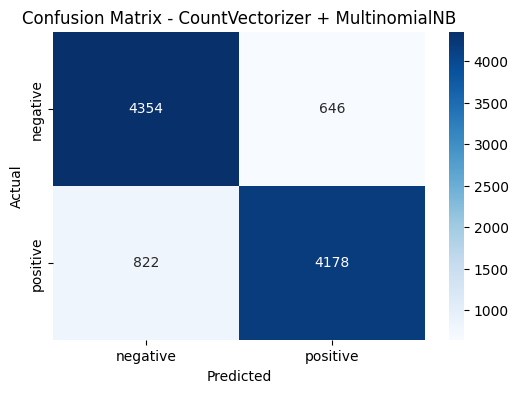

In [12]:
cm = confusion_matrix(y_test, y_pred_count, labels=['negative', 'positive'])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'positive'],
            yticklabels=['negative', 'positive'])
plt.title("Confusion Matrix - CountVectorizer + MultinomialNB")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 13. Model 2: TF-IDF + Multinomial Naive Bayes

Bây giờ ta thử `TfidfVectorizer`.

Ý tưởng:

- Từ xuất hiện nhiều trong một review → quan trọng hơn
- Từ xuất hiện quá phổ biến trong toàn bộ dataset → giảm độ quan trọng

Ví dụ các từ như `movie`, `film`, `character` có thể xuất hiện rất nhiều nên chưa chắc giúp phân loại tốt.

In [13]:
model_tfidf_nb = Pipeline([
    ('vectorizer', TfidfVectorizer(stop_words='english', max_features=20000, ngram_range=(1,2))),
    ('classifier', MultinomialNB())
])

model_tfidf_nb.fit(X_train, y_train)

y_pred_tfidf = model_tfidf_nb.predict(X_test)

acc_tfidf = accuracy_score(y_test, y_pred_tfidf)
print("Accuracy - TF-IDF + MultinomialNB:", acc_tfidf)

Accuracy - TF-IDF + MultinomialNB: 0.8696


In [14]:
print(classification_report(y_test, y_pred_tfidf))

              precision    recall  f1-score   support

    negative       0.88      0.85      0.87      5000
    positive       0.86      0.89      0.87      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



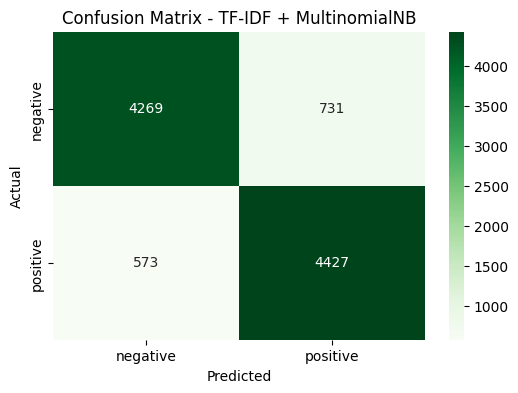

In [15]:
cm = confusion_matrix(y_test, y_pred_tfidf, labels=['negative', 'positive'])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['negative', 'positive'],
            yticklabels=['negative', 'positive'])
plt.title("Confusion Matrix - TF-IDF + MultinomialNB")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 14. So sánh 2 model

In [16]:
results = pd.DataFrame({
    'Model': [
        'CountVectorizer + MultinomialNB',
        'TF-IDF + MultinomialNB'
    ],
    'Accuracy': [acc_count, acc_tfidf]
})

results

,Model,Accuracy
0,CountVectorizer + MultinomialNB,0.8532
1,TF-IDF + MultinomialNB,0.8696


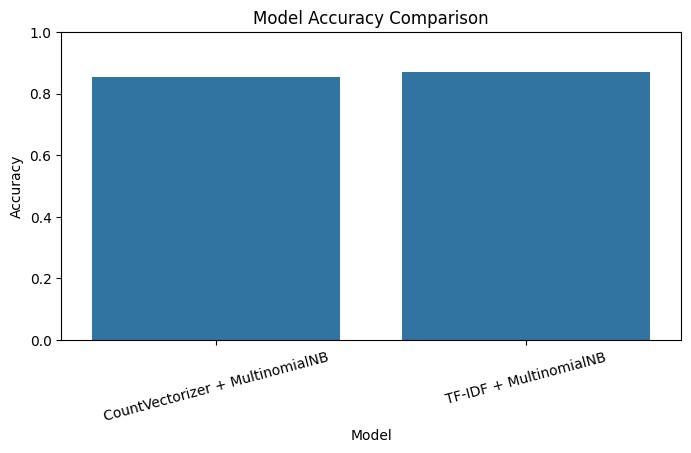

In [17]:
plt.figure(figsize=(8,4))
sns.barplot(data=results, x='Model', y='Accuracy')
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=15)
plt.show()

## 15. Dự đoán review mới

Ta viết hàm để nhập review mới và model trả về:

- Label dự đoán
- Xác suất `negative`
- Xác suất `positive`

In [18]:
def predict_review(review, model):
    cleaned = clean_text(review)
    pred = model.predict([cleaned])[0]
    proba = model.predict_proba([cleaned])[0]
    classes = model.classes_
    proba_dict = dict(zip(classes, proba))
    
    print("Original review:", review)
    print("Cleaned review:", cleaned)
    print("Prediction:", pred)
    print("Probability:")
    for label, p in proba_dict.items():
        print(f"  {label}: {p:.4f}")

In [19]:
predict_review("This movie was amazing, emotional, and beautifully acted", model_tfidf_nb)

Original review: This movie was amazing, emotional, and beautifully acted
Cleaned review: this movie was amazing emotional and beautifully acted
Prediction: positive
Probability:
  negative: 0.0732
  positive: 0.9268


In [20]:
predict_review("The movie was boring, too long, and completely disappointing", model_tfidf_nb)

Original review: The movie was boring, too long, and completely disappointing
Cleaned review: the movie was boring too long and completely disappointing
Prediction: negative
Probability:
  negative: 0.9241
  positive: 0.0759


In [21]:
predict_review("The film was not good and I would not recommend it", model_tfidf_nb)

Original review: The film was not good and I would not recommend it
Cleaned review: the film was not good and i would not recommend it
Prediction: positive
Probability:
  negative: 0.4000
  positive: 0.6000


## 16. Lưu model

Sau khi train xong, ta có thể lưu model để dùng lại.

File output:

```text
naive_bayes_sentiment_model.pkl
```

In [24]:
model_dir = "models"
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, "naive_bayes_sentiment_model.pkl")
joblib.dump(model_tfidf_nb, model_path)

print(f"Model saved as {model_path}")

Model saved as models\naive_bayes_sentiment_model.pkl


## 17. Load model từ folder `models`

In [32]:
model_path = os.path.join("models", "naive_bayes_sentiment_model.pkl")
loaded_model = joblib.load(model_path)

print(f"Loaded model from {model_path}")

predict_review("The beginning was so so boring, and the later parts were well.", loaded_model)

Loaded model from models\naive_bayes_sentiment_model.pkl
Original review: The beginning was so so boring, and the later parts were well.
Cleaned review: the beginning was so so boring and the later parts were well
Prediction: negative
Probability:
  negative: 0.6206
  positive: 0.3794


## 18. Giải thích kết quả

Nếu model dự đoán `positive`, nghĩa là dựa trên các từ trong review, xác suất review thuộc nhóm positive cao hơn negative.

Nếu model dự đoán `negative`, nghĩa là các từ trong review giống nhóm negative hơn.

Ví dụ:

```text
"amazing", "great", "excellent", "wonderful"
```

thường đẩy xác suất về `positive`.

```text
"boring", "bad", "terrible", "disappointing"
```

thường đẩy xác suất về `negative`.

Nhưng Naive Bayes có điểm yếu: nó không hiểu ngữ cảnh sâu.

Ví dụ:

```text
"not good"
```

Model có thể thấy từ `good` và đoán sai nếu xử lý phủ định chưa tốt.

## 19. Bài tập tự luyện

### Bài 1

Thay đổi tham số:

```python
max_features=5000
max_features=10000
max_features=30000
```

Quan sát Accuracy thay đổi như thế nào.

---

### Bài 2

Thay đổi:

```python
ngram_range=(1,1)
ngram_range=(1,2)
ngram_range=(1,3)
```

Câu hỏi:

- Bigram có giúp model hiểu cụm từ tốt hơn không?
- Ví dụ `not good`, `very bad`, `highly recommend`.

---

### Bài 3

Thay `MultinomialNB()` bằng:

```python
MultinomialNB(alpha=0.1)
MultinomialNB(alpha=0.5)
MultinomialNB(alpha=1.0)
MultinomialNB(alpha=2.0)
```

`alpha` là tham số Laplace smoothing.

---

### Bài 4

Tự viết 5 review mới:

- 2 positive
- 2 negative
- 1 câu khó, có phủ định như `not good`, `not bad`

Sau đó dùng hàm `predict_review()` để kiểm tra.

## 20. Tổng kết kiến thức

Naive Bayes dùng tốt cho text classification vì:

- Nhanh
- Dễ hiểu
- Dễ triển khai
- Hiệu quả với dữ liệu dạng word frequency

Pipeline cơ bản:

```text
Raw review → Clean text → Vectorizer → MultinomialNB → Prediction
```

Trong bài này:

```text
IMDB reviews → sentiment positive/negative
```

Đây là bài nền tảng rất quan trọng trước khi học các model NLP nâng cao như:

- Logistic Regression for text classification
- SVM for sentiment analysis
- Word Embedding
- LSTM
- BERT